# Telco Costumer Churn Prediction

## Introduction

This is a small project for me, an aspiring data scientist, to practice exploratory data analysis and machine learning concepts and techniques using a very famous IBM dataset for churning prediction. I'm obsessively studying machine learning and I'm very excited to finally be able to aplly a few concepts that I studied along the way. I know that it won't be perfect, but I would be so pleased to receive comments and tips from the community so I can improve and made better predictive models in the future!

# Loading the data

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The dataset seems fine, at a first glance there are no null values, but as we can see, the 'TotalCharges' column should be a numeric data type, but instead it is an object data type. We must remember that later to check what's wrong with that.

# Data Cleaning and Feature Enginnering

Now I need to prepare the dataset to be splitted into the train and test sets, but in order to do that, first there are a few transformations and light analysis to do. First, the ID column is useless to the training, so we don't need it

In [4]:
#Basic treatments: First removing the ID column (useless for model training purposes), than starting to creating and modifying a few columns

def internet_map(x):
    if x =='No':
        return 0
    else:
        return 1

df = df.drop(columns=['customerID'])
df.rename(columns={'InternetService': 'InternetType'}, inplace=True)
df['InternetService'] = df['InternetType'].map(internet_map)

# Now we need to convert the 'TotalChanges' column to numeric data type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
# Next it's time to onvert the boolean columns
bool_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
df[bool_cols] = df[bool_cols].apply(lambda x: x.map({'Yes': 1, 'No': 0}))

# Let's check what changed until now
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetType,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,InternetService
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,1
1,0,0,0,0,34,1,No,DSL,Yes,No,...,No,No,No,One year,0,Mailed check,56.95,1889.50,0,1
2,0,0,0,0,2,1,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,...,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,1
4,1,0,0,0,2,1,No,Fiber optic,No,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,1


Ok, so I created a new column that tells us if the client has internet service and modified the original 'InternetService' to 'InternetType' so we can have both information to provide the model more information.
Next up, I thought that would be a good ideia to have a new feature that would inform how many services a client is subscribed.

In [6]:
# Listing all the possible services
add_services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

# Creating the column with that information
df['TotalServices'] = (df[add_services] == 'Yes').sum(axis=1)
df['TotalServices'] = df['TotalServices'] + (df['PhoneService'] == 1) + (df['InternetService'] == 1)
df['ChargesPerTenure'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetType,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,InternetService,TotalServices,ChargesPerTenure
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,Month-to-month,1,Electronic check,29.85,29.85,0,1,2,29.850000
1,0,0,0,0,34,1,No,DSL,Yes,No,...,No,One year,0,Mailed check,56.95,1889.50,0,1,4,55.573529
2,0,0,0,0,2,1,No,DSL,Yes,Yes,...,No,Month-to-month,1,Mailed check,53.85,108.15,1,1,4,54.075000
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,...,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,1,4,40.905556
4,1,0,0,0,2,1,No,Fiber optic,No,No,...,No,Month-to-month,1,Electronic check,70.70,151.65,1,1,2,75.825000


Perfect. We cleaned and feature engineered our dataset, giving more context and information to inform our model so it can make batter predictions.
Note that I did not imputed any values to the NaN values of the 'TotalCharges' column after the data type conversion, as we should first split the dataset into train and test before any mathematical modification.

# Splitting the test

## Split the test and forget the test set for a while!

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.shape, test_set.shape

((5634, 23), (1409, 23))

In [9]:
test_set = test_set.drop(columns=['Churn'])
test_set_ids = test_set.index.copy()

In [10]:
X = train_set.drop(columns=['Churn'])
y = train_set[['Churn']]

# Training the model

## Dealing with the missing information first

As remembered, there is a very small portion of data that is missing, but yet is still data, so I want to take a better look into that.

In [11]:
train_set.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetType         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        10
Churn                0
InternetService      0
TotalServices        0
ChargesPerTenure    10
dtype: int64

In [12]:
train_set.loc[train_set['TotalCharges'].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetType,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,InternetService,TotalServices,ChargesPerTenure
6754,0,0,0,1,0,1,Yes,DSL,Yes,Yes,...,No,Two year,1,Bank transfer (automatic),61.90,NaN,0,1,6,NaN
1340,1,0,1,1,0,0,No phone service,DSL,Yes,Yes,...,No,Two year,0,Credit card (automatic),56.05,NaN,0,1,6,NaN
3826,0,0,1,1,0,1,Yes,No,No internet service,No internet service,...,No internet service,Two year,0,Mailed check,25.35,NaN,0,0,2,NaN
5218,0,0,1,1,0,1,No,No,No internet service,No internet service,...,No internet service,One year,1,Mailed check,19.70,NaN,0,0,1,NaN
3331,0,0,1,1,0,1,No,No,No internet service,No internet service,...,No internet service,Two year,0,Mailed check,19.85,NaN,0,0,1,NaN
936,1,0,1,1,0,1,No,DSL,Yes,Yes,...,Yes,Two year,0,Mailed check,80.85,NaN,0,1,7,NaN
753,0,0,0,1,0,1,No,No,No internet service,No internet service,...,No internet service,Two year,0,Mailed check,20.25,NaN,0,0,1,NaN
4380,1,0,1,1,0,1,No,No,No internet service,No internet service,...,No internet service,Two year,0,Mailed check,20.00,NaN,0,0,1,NaN
488,1,0,1,1,0,0,No phone service,DSL,Yes,No,...,No,Two year,1,Bank transfer (automatic),52.55,NaN,0,1,5,NaN
1082,0,0,1,1,0,1,Yes,No,No internet service,No internet service,...,No internet service,Two year,0,Mailed check,25.75,NaN,0,0,2,NaN


Ok, normally here I would probably input a median value of the column, but I noticed that the all the 'tenure' values for the 'TotalCharges' NaN values are 0, so I guess that it's safe to assume that if you have 0 as tenure, it means that you don't have anything to pay until that point, so instead of the median value of the column, I believe it is safer to imput 0 as value

In [13]:
X[['TotalCharges', 'ChargesPerTenure']] = X[['TotalCharges', 'ChargesPerTenure']].fillna(0)

## Splitting the train set the model training

In [14]:
X_train_set, X_test_set, y_train_set, y_test_set  = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_set.shape, X_test_set.shape, y_train_set.shape, y_test_set.shape

((4507, 22), (1127, 22), (4507, 1), (1127, 1))

## Pipeline building and training

In [15]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'TotalServices', 'ChargesPerTenure'
           ]

cat_cols = ['gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'PhoneService', 'PaperlessBilling', 'InternetService'
           ]

multiclass_cols = ['MultipleLines', 'InternetType', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'PaymentMethod'
                  ]

contract_order = [['Month-to-month', 'One year', 'Two year']]
ordinal_transformer = OrdinalEncoder(categories=contract_order)

pre_processing = ColumnTransformer(
    transformers=[('num', StandardScaler(), num_cols),
                  ('ord', ordinal_transformer, ['Contract']),
                  ('bin', OneHotEncoder(drop='if_binary'), cat_cols),
                  ('cat', OneHotEncoder(), multiclass_cols)
                 ])




# I'll try both Random Forest and Logistic Regression:
forest_model = Pipeline(steps=[
    ('preprocessor', pre_processing),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          random_state=42,
                                          class_weight='balanced'))
])

logreg_model = Pipeline(steps=[
    ('preprocessor', pre_processing),
    ('classifier', LogisticRegression(random_state=42,
                                      class_weight='balanced'))
])

In [16]:
forest_model.fit(X_train_set, y_train_set.values.ravel())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'ChargesPerTenure']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('bin',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'PaperlessBilling',
                                                   'InternetService']),
                                                 ('cat', OneHotEncoder(),
                                                  ['MultipleLines',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [17]:
logreg_model.fit(X_train_set, y_train_set.values.ravel())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'ChargesPerTenure']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('bin',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'PaperlessBilling',
                                                   'InternetService']),
                                                 ('cat', OneHotEncoder(),
                                                  ['MultipleLines',
                                                   'InternetType',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [18]:
p_forest = forest_model.predict_proba(X_test_set)[:, 1]

# For personal remember the following line set a threshold:
p_forest_binary = (p_forest > 0.5).astype(int)
p_forest

array([0.2 , 0.31, 0.53, ..., 0.24, 0.05, 0.51])

In [19]:
p_logreg = logreg_model.predict_proba(X_test_set)[:, 1]

# For personal remember the following line set a threshold:
p_logreg_binary = (p_logreg > 0.5).astype(int)
p_logreg

array([0.40677226, 0.52518822, 0.65579583, ..., 0.47500634, 0.12103341,
       0.60968572])

# Tests
## ROC-AUC Score

In [20]:
auc_score1 = roc_auc_score(y_test_set, p_forest)
auc_score2 = roc_auc_score(y_test_set, p_logreg)

print(f"The AUC of my Random Forest Classifier model is {auc_score1}")
print(f"The AUC of my Logistic Regression model is {auc_score2}")

The AUC of my Random Forest Classifier model is 0.822988712057756
The AUC of my Logistic Regression model is 0.8412468589206654


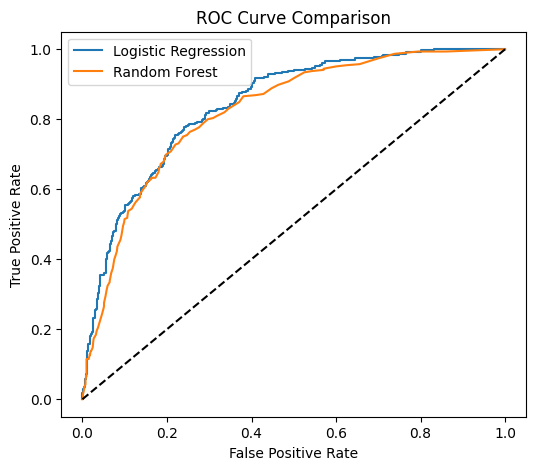

In [21]:
fpr_log, tpr_log, _ = roc_curve(y_test_set, p_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test_set, p_forest)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Confusion matrix

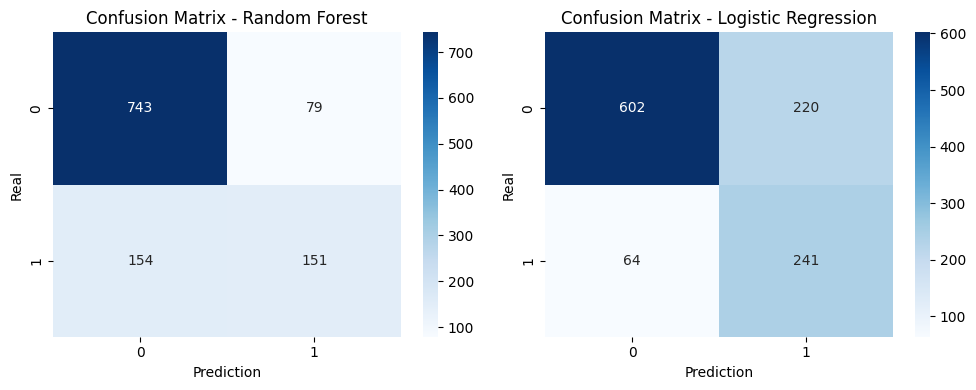

In [22]:
cm1 = confusion_matrix(y_test_set, p_forest_binary)
cm2 = confusion_matrix(y_test_set, p_logreg_binary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Real')
axes[0].set_title('Confusion Matrix - Random Forest')

sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Prediction')
axes[1].set_ylabel('Real')
axes[1].set_title('Confusion Matrix - Logistic Regression')

plt.tight_layout()
plt.show()

In [23]:
print(cm1)
print()
print(cm2)

[[743  79]
 [154 151]]

[[602 220]
 [ 64 241]]


# Conclusion

Although the AUC Score looks good in both models, the confusion matrices shows what the AUC Score don't: both models needs improvements. In the Random Forest matrix, almost 50% of the clients weren't "catched" by the model, and in the Logistic Regression matrix, 220 clients era false positives.

The work is not perfect, in a real world scenario it probably would not be useful since what we want is that the clients do not cancel the company's service. But I also believe that with a better hyperparameters tunning or a better feature selection, the results could be better. In future versions,

I'll try to better fit the model and share the results but, for a first try, it was an amazing experience and I hope that from now on, my next works will improve significantly, thank you!